# Training Model

input_shape (11696, 900, 2) (11696, 540, 2) (11696, 180, 2)
Learning rate:  0.0010000000474974513
Epoch 1/100
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6315 - loss: 1.0143
Epoch 1: val_accuracy improved from -inf to 0.83603, saving model to weights.best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6331 - loss: 1.0110 - val_accuracy: 0.8360 - val_loss: 0.6348 - learning_rate: 0.0010
Learning rate:  0.0010000000474974513
Epoch 2/100
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8210 - loss: 0.6500
Epoch 2: val_accuracy improved from 0.83603 to 0.85637, saving model to weights.best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8213 - loss: 0.6492 - val_accuracy: 0.8564 - val_loss: 0.5389 - learning_rate: 0.0010
Learning rate:  0.0010000000474974513
Epoch 3/100
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8524 - loss: 0.5425
Epoch 3: val_accuracy improved from 0.85637 to 0.86236, saving model to weights.best.keras
92/92 ━━━━━━━━━━━━

D:\Py Env\jayadeep\Lib\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


530/530 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9040 - loss: 0.3178
530/530 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
acc: 0.9064620832103866, sn: 0.8600924499229584, sp: 0.935246293639407, f1: 0.8756765236489137
Processing Time: 274.22161507606506 seconds


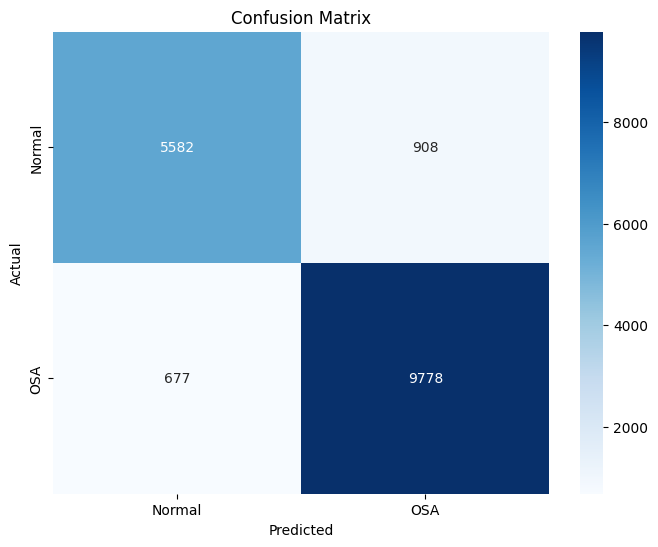

In [1]:
"""NOTES: Batch data is different each time in keras, which result in slight differences in results."""
import pickle
import keras
import numpy as np
import pandas as pd
import os
from keras.layers import Dropout, MaxPooling1D, Reshape, multiply, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from keras.models import load_model
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from scipy.interpolate import splev, splrep
from sklearn.metrics import confusion_matrix, f1_score
import random
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16  # Assuming VGG16 pre-trained model
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import time

base_dir = "E:/Work/doc/jayadeep/Toward-Sleep-Apnea-Detection-With-LightWeight-multi-Scaled-fusion-Network-Main/dataset"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
ir = 3  # interpolate interval
before = 2
after = 2
# normalize
scaler = lambda arr: (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

def load_data(path):
    tm = np.arange(0, (before + 1 + after) * 60, step=1 / float(ir))
    with open(os.path.join(base_dir, path), 'rb') as f:  # read preprocessing result
        apnea_ecg = pickle.load(f)
    x_train1,x_train2,x_train3 = [],[],[]
    o_train, y_train = apnea_ecg["o_train"], apnea_ecg["y_train"]
    groups_train = apnea_ecg["groups_train"]
    for i in range(len(o_train)):
        (rri_tm, rri_signal), (ampl_tm, ampl_siganl) = o_train[i]
        # Curve interpolation
        rri_interp_signal = splev(tm, splrep(rri_tm, scaler(rri_signal), k=3), ext=1)
        ampl_interp_signal = splev(tm, splrep(ampl_tm, scaler(ampl_siganl), k=3), ext=1)
        x_train1.append([rri_interp_signal, ampl_interp_signal])  # 5-minute-long segment
        x_train2.append([rri_interp_signal[180:720], ampl_interp_signal[180:720]])  # 3-minute-long segment
        x_train3.append([rri_interp_signal[360:540], ampl_interp_signal[360:540]])  # 1-minute-long segment
    x_training1,x_training2,x_training3,y_training,groups_training = [],[],[],[],[]
    x_val1,x_val2,x_val3,y_val,groups_val = [],[],[],[],[]

    trainlist = random.sample(range(len(o_train)),int(len(o_train)*0.7))
    num = [i for i in range(16709)]
    vallist = set(num) - set(trainlist)
    vallist = list(vallist)
    for i in trainlist:
        x_training1.append(x_train1[i])
        x_training2.append(x_train2[i])
        x_training3.append(x_train3[i])
        y_training.append(y_train[i])
        groups_training.append(groups_train[i])
    for i in vallist:
        x_val1.append(x_train1[i])
        x_val2.append(x_train2[i])
        x_val3.append(x_train3[i])
        y_val.append(y_train[i])
        groups_val.append(groups_train[i])
    x_training1 = np.array(x_training1, dtype="float32").transpose((0, 2, 1))
    x_training2 = np.array(x_training2, dtype="float32").transpose((0, 2, 1))
    x_training3 = np.array(x_training3, dtype="float32").transpose((0, 2, 1))
    y_training = np.array(y_training, dtype="float32")
    x_val1 = np.array(x_val1, dtype="float32").transpose((0, 2, 1))
    x_val2 = np.array(x_val2, dtype="float32").transpose((0, 2, 1))
    x_val3 = np.array(x_val3, dtype="float32").transpose((0, 2, 1))
    y_val = np.array(y_val, dtype="float32")
    x_test1,x_test2,x_test3 = [],[],[]
    o_test, y_test = apnea_ecg["o_test"], apnea_ecg["y_test"]
    groups_test = apnea_ecg["groups_test"]
    for i in range(len(o_test)):
        (rri_tm, rri_signal), (ampl_tm, ampl_siganl) = o_test[i]
        # Curve interpolation
        rri_interp_signal = splev(tm, splrep(rri_tm, scaler(rri_signal), k=3), ext=1)
        ampl_interp_signal = splev(tm, splrep(ampl_tm, scaler(ampl_siganl), k=3), ext=1)
        x_test1.append([rri_interp_signal, ampl_interp_signal])
        x_test2.append([rri_interp_signal[180:720], ampl_interp_signal[180:720]])
        x_test3.append([rri_interp_signal[360:540], ampl_interp_signal[360:540]])
    x_test1 = np.array(x_test1, dtype="float32").transpose((0, 2, 1))
    x_test2 = np.array(x_test2, dtype="float32").transpose((0, 2, 1))
    x_test3 = np.array(x_test3, dtype="float32").transpose((0, 2, 1))
    y_test = np.array(y_test, dtype="float32")

    return x_training1, x_training2, x_training3, y_training, groups_training, x_val1, x_val2, \
           x_val3, y_val, groups_val, x_test1, x_test2, x_test3, y_test, groups_test


def lr_schedule(epoch, lr):
    if epoch > 70 and (epoch - 1) % 10 == 0:
        lr *= 0.1
    print("Learning rate: ", lr)
    return lr


def create_model(input_a_shape, input_b_shape, input_c_shape, weight=1e-3):
    # SA-CNN-3
    input1 = Input(shape=input_a_shape)
    x1 = Conv1D(16, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(weight), bias_regularizer=l2(weight))(input1)
    x1 = Conv1D(24, kernel_size=11, strides=2, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x1)
    x1 = MaxPooling1D(pool_size=3, padding="same")(x1)
    x1 = Conv1D(32, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x1)
    x1 = MaxPooling1D(pool_size=5, padding="same")(x1)

    # SA-CNN-2
    input2 = Input(shape=input_b_shape)
    x2 = Conv1D(16, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(weight), bias_regularizer=l2(weight))(input2)
    x2 = Conv1D(24, kernel_size=11, strides=2, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x2)
    x2 = MaxPooling1D(pool_size=3, padding="same")(x2)
    x2 = Conv1D(32, kernel_size=11, strides=3, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x2)

    # SA-CNN-1
    input3 = Input(shape=input_c_shape)
    x3 = Conv1D(16, kernel_size=11, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(weight), bias_regularizer=l2(weight))(input3)
    x3 = Conv1D(24, kernel_size=11, strides=2, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x3)
    x3 = MaxPooling1D(pool_size=3, padding="same")(x3)
    x3 = Conv1D(32, kernel_size=1, strides=1, padding="same", activation="relu", kernel_initializer="he_normal",
                kernel_regularizer=l2(1e-3), bias_regularizer=l2(weight))(x3)

    # Channel-wise attention module
    concat = keras.layers.concatenate([x1, x2, x3], name="Concat_Layer", axis=-1)
    squeeze = GlobalAveragePooling1D()(concat)
    excitation = Dense(48, activation='relu')(squeeze)
    excitation = Dense(96, activation='sigmoid')(excitation)
    excitation = Reshape((1, 96))(excitation)
    scale = multiply([concat, excitation])
    x = GlobalAveragePooling1D()(scale)
    dp = Dropout(0.5)(x)
    outputs = Dense(2, activation='softmax', name="Output_Layer")(dp)
    model = Model(inputs=[input1, input2, input3], outputs=outputs)
    return model


if __name__ == "__main__":
    # load_data
    path = "apnea-ecg.pkl"
    x_train1, x_train2, x_train3, y_train, groups_train, x_val1, x_val2,\
    x_val3, y_val, groups_val, x_test1, x_test2, x_test3, y_test, groups_test = load_data(path)
    y_train = keras.utils.to_categorical(y_train, num_classes=2)  # Convert to two categories
    y_val = keras.utils.to_categorical(y_val, num_classes=2)
    y_test = keras.utils.to_categorical(y_test, num_classes=2)
    print('input_shape', x_train1.shape, x_train2.shape, x_train3.shape)

    # training
    model = create_model(x_train1.shape[1:], x_train2.shape[1:], x_train3.shape[1:])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # filepath = 'weights.best.hdf5'
    filepath = 'weights.best.keras'
    
    checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
    lr_scheduler = LearningRateScheduler(lr_schedule)
    callbacks_list = [lr_scheduler, checkpoint]
    start_time = time.time()
    history = model.fit([x_train1, x_train2, x_train3], y_train, batch_size=128, epochs=100,
                        validation_data=([x_val1, x_val2, x_val3], y_val), callbacks=callbacks_list)
         # test

    # filepath = "./drive/MyDrive/ColabNotebooks/Toward-Sleep-Apnea-Detection-With-LightWeight-multi-Scaled-fusion-Network-Main/models/weights.best.hdf5"
    filepath = "E:/Work/doc/jayadeep/Toward-Sleep-Apnea-Detection-With-LightWeight-multi-Scaled-fusion-Network-Main/models/weights.best.hdf5"
    
    model = load_model(filepath)
    loss, accuracy = model.evaluate([x_test1, x_test2, x_test3], y_test)
    # save prediction score
    y_score = model.predict([x_test1, x_test2, x_test3])
    end_time = time.time()
    processing_time = end_time - start_time
    output = pd.DataFrame({"y_true": y_test[:, 1], "y_score": y_score[:, 1], "subject": groups_test})
    # output.to_csv("/content/drive/MyDrive/ColabNotebooks/Toward-Sleep-Apnea-Detection-With-LightWeight-multi-Scaled-fusion-Network-Main/utils/code_for_calculating_per_recording/output/SE-MSCNN.csv", index=False)
    output.to_csv("E:/Work/doc/jayadeep/Toward-Sleep-Apnea-Detection-With-LightWeight-multi-Scaled-fusion-Network-Main/utils/code_for_calculating_per_recording/outputx/SE-MSCNN.csv", index=False)
    
    y_true, y_pred = np.argmax(y_test, axis=-1), np.argmax(model.predict([x_test1, x_test2, x_test3], batch_size=1024, verbose=1), axis=-1)
    C = confusion_matrix(y_true, y_pred, labels=(1, 0))
    TP, TN, FP, FN = C[0, 0], C[1, 1], C[1, 0], C[0, 1]
    acc, sn, sp = 1. * (TP + TN) / (TP + TN + FP + FN), 1. * TP / (TP + FN), 1. * TN / (TN + FP)
    f1 = f1_score(y_true, y_pred, average='binary')
    print("acc: {}, sn: {}, sp: {}, f1: {}".format(acc, sn, sp, f1))
    print("Processing Time:", processing_time, "seconds")
    plt.figure(figsize=(8, 6))
    class_names = ['Normal', 'OSA']
    sns.heatmap(C, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [2]:
start_time = time.time()
print("StartTime:", start_time, "seconds")
y_score = model.predict([x_test1, x_test2, x_test3])
end_time = time.time()
processing_time = end_time - start_time
print("Processing Time:", processing_time, "seconds")

StartTime: 1717067665.2255938 seconds
530/530 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step
Processing Time: 8.345731496810913 seconds


In [45]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_1 (InputLayer)          │ (None, 900, 2)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 900, 16)           │             368 │ input_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_2 (InputLayer)          │ (None, 540, 2)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_3 (InputLayer)          │ (None, 180, 2)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 450, 24)           │           4,248 │ conv1d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_4 (Conv1D)             │ (None, 540, 16)           │             368 │ input_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_7 (Conv1D)             │ (None, 180, 16)           │             368 │ input_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 150, 24)           │               0 │ conv1d_2[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_5 (Conv1D)             │ (None, 270, 24)           │           4,248 │ conv1d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_8 (Conv1D)             │ (None, 90, 24)            │           4,248 │ conv1d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 150, 32)           │           8,480 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_3               │ (None, 90, 24)            │               0 │ conv1d_5[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_4               │ (None, 30, 24)            │               0 │ conv1d_8[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_2               │ (None, 30, 32)            │               0 │ conv1d_3[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_6 (Conv1D)             │ (None, 30, 32)            │           8,480 │ max_pooling1d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 41,164 (160.80 KB)

 Trainable params: 41,162 (160.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# Run this first for Grad-Cam ++ (Final)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll

# Function to plot multicolored lines
def multicolored_lines(x, y, heatmap, title_name):
    fig, ax = plt.subplots()  # Create a figure and an axes
    lc = colorline(x, y, heatmap, cmap='rainbow')  # Generate the line collection
    plt.colorbar(lc)  # Add a colorbar to the plot
    lc.set_linewidth(2)  # Set the linewidth of the lines
    lc.set_alpha(0.8)  # Set the transparency of the lines
    plt.xlim(x.min(), x.max())  # Set the limits of the x-axis
    plt.ylim(y.min(), y.max())  # Set the limits of the y-axis
    plt.title(title_name)  # Set the title of the plot
    plt.grid(False)  # Disable the grid
    plt.show()  # Display the plot

# Function to create a line collection with colors based on a colormap
def colorline(x, y, heatmap, cmap='rainbow'):
    z = np.array(heatmap)  # Convert heatmap to a numpy array
    points = np.array([x, y]).T.reshape(-1, 1, 2)  # Create points array
    segments = np.concatenate([points[:-1], points[1:]], axis=1)  # Create line segments
    lc = mcoll.LineCollection(segments, array=z, cmap=cmap)  # Create a line collection
    ax = plt.gca()  # Get current axes
    ax.add_collection(lc)  # Add the line collection to the axes
    return lc  # Return the line collection

def compute_cam_1d_output (model, data , layer_name , N):#Explainability
        """
        model: The Deep Learning model
        data : A input data. Data shape has to be (n,1,1)
        layer_name : The target layer for explanation
        N: signal length in seconds
        """
        # input layer, model output layer and target layer
        grad_model = tf.keras.models.Model(inputs=[model.inputs[0], model.inputs[1], model.inputs[2]], outputs=[model.get_layer(layer_name).output, model.output])

        # Getting gradients of input layer, model output layer (predictions) and target layer
        with tf.GradientTape() as tape:
            conv_outs, predictions = grad_model(data) 
            class_idx = tf.argmax(predictions[0])
            y_c = predictions[:, class_idx]
            tape.watch(conv_outs)
            # Define a more complex loss function
            predictions = conv_outs * 2.0  # For example purposes, let's assume this is the model's output
            loss = tf.reduce_mean((predictions - 1.0) ** 2) + tf.reduce_sum(y_c)  # Mean squared error + some constant term

        batch_grads = tape.gradient(loss, conv_outs)
        grads = batch_grads[0]

        # The explainability graphing part expects the input of (x, y) so y must be the amplitude signals or the R-R interval signals of the shape (n,1)
        # Choose the index of the sample you want to extract
        sample_index = 0  # Change this to the desired sample index
        
        # Extract one sample (shape: (N, 2))
        # Modify tis part to pick R-R interval or the amplitude interval
        sample = data[0][sample_index, :, :]
        
        # Extract one feature from the sample (shape: (N,))
        feature_index = 0  # Change this to 1 if you want the other feature
        single_feature = sample[:, feature_index]
        
        # Reshape the extracted feature to (N, 1, 1)
        reshaped_feature = tf.reshape(single_feature, (N, 1))
    
        # First, second and third derivative of output gradient
        y_c = tf.reshape(y_c, (-1, 1))  # Reshape y_c to have shape [1, 1] or [-1, 1] depending on your needs
        first = tf.exp(y_c) * grads
        second = tf.exp(y_c) * tf.pow(grads, 2)
        third = tf.exp(y_c) * tf.pow(grads, 3)
        
        # Compute salienty maps for the class_idx prediction
        global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
        alpha_num = second
        alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1,1,first.shape[1]))
        alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
        alphas = alpha_num / alpha_denom
        weights = tf.maximum(first, 0.0)
        alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
        alphas /= tf.reshape(alpha_normalization_constant, shape=(1,1,first.shape[1]))
        alphas_thresholding = np.where(weights, alphas, 0.0)
        
        alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0),axis=0)
        alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                          tf.ones(alpha_normalization_constant.shape))
        
        alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1,1,first.shape[1]))
        deep_linearization_weights = tf.reduce_sum(tf.reshape((weights*alphas), shape=(-1,first.shape[1])), axis=0)
        grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)
        
        # Normalization
        cam = np.maximum(grad_CAM_map, 0)
        cam = cam / np.max(cam)
        
        # Turn result into a heatmap
        heatmap=[]
        heatmap.append(cam.tolist())
        big_heatmap = cv2.resize(np.array(heatmap), dsize=(data[0].shape[0], 500),interpolation=cv2.INTER_CUBIC)
        x = np.linspace(0, N, data[0].shape[0])
        # plt.style.use("seaborn-whitegrid")
        plt.style.use("ggplot")
        # multicolored_lines(x,np.array([i[0] for i in data[0][:,2]]),big_heatmap[0],f"GradCAM ++ Visualization")
        multicolored_lines(x[0:N],np.array([i[0] for i in reshaped_feature]),big_heatmap[0],f"GradCAM ++ Visualization")

In [8]:
# Reshaping for Grad-Cam+ input
xav1= np.array(x_train1)
print("xav1.shape:",xav1.shape)
xav1_reshaped=np.squeeze(xav1[:1], axis=0)  #xav1.reshape(-1,1,1)
print("xav1_reshaped:",xav1_reshaped.shape)


xav2= np.array(x_train2)
print("xav2.shape:",xav2.shape)
xav2_reshaped=np.squeeze(xav2[:1], axis=0)   #xav2.reshape(-1,1,1)
print("xav2_reshaped:",xav2_reshaped.shape)

xav3= np.array(x_train3)
print("xav3.shape:",xav3.shape)
xav3_reshaped=np.squeeze(xav3[:1], axis=0)   #xav3.reshape(-1,1,1)
print("xav3_reshaped:",xav3_reshaped.shape)

xav1.shape: (11696, 900, 2)
xav1_reshaped: (900, 2)
xav2.shape: (11696, 540, 2)
xav2_reshaped: (540, 2)
xav3.shape: (11696, 180, 2)
xav3_reshaped: (180, 2)


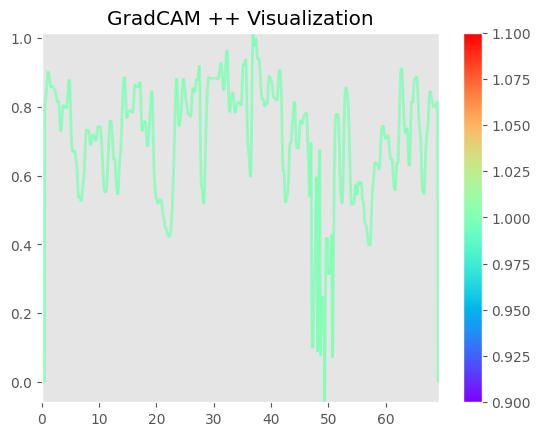

In [44]:
compute_cam_1d_output (model,[xav1, xav2, xav3],'Output_Layer',900)

# Trial and Error - Ignore the part here on

In [ ]:
len([x_test1, x_test2, x_test3])
print(x_test1.shape)

In [ ]:
len(model.inputs)
print(model.inputs[0].shape)

In [ ]:
# Print Shapes
print("Shapes before reshaping")
print("x_train1.shape:",x_train1.shape)
print("x_train2.shape:",x_train2.shape)
print("x_train3.shape:",x_train3.shape)

In [ ]:
# Reshaping
xav1= np.array(x_train1)
print("xav1.shape:",xav1.shape)
xav1_reshaped=np.squeeze(xav1[:1], axis=0)  #xav1.reshape(-1,1,1)
print("xav1_reshaped:",xav1_reshaped.shape)


xav2= np.array(x_train2)
print("xav2.shape:",xav2.shape)
xav2_reshaped=np.squeeze(xav2[:1], axis=0)   #xav2.reshape(-1,1,1)
print("xav2_reshaped:",xav2_reshaped.shape)

xav3= np.array(x_train3)
print("xav3.shape:",xav3.shape)
xav3_reshaped=np.squeeze(xav3[:1], axis=0)   #xav3.reshape(-1,1,1)
print("xav3_reshaped:",xav3_reshaped.shape)


# y_test_

In [ ]:
# def inspect_apnea_ecg(file_path):
#     with open(file_path, 'rb') as f:
#         apnea_ecg = pickle.load(f)

#     for key, value in apnea_ecg.items():
#         print(f"{key}: type = {type(value)}, length = {len(value)}")
#         # if isinstance(value, (list, np.ndarray)):
#             # print(f"First element of {key}: {value[0]}")
#         print("------------------------------------------------------")

# # Provide the path to the pickle file
path = os.path.join(base_dir, "apnea-ecg.pkl")
# inspect_apnea_ecg(path)
with open(path, 'rb') as f:
    apnea_ecg_temp = pickle.load(f)

In [ ]:
apnea_keys = list(apnea_ecg_temp.keys())
print("Keys in apnea: ", apnea_keys)
print("Length of o_test:", len(apnea_ecg_temp['o_test']))
print("Length of y_test:", len(apnea_ecg_temp['y_test']))
x_test1.shape

In [ ]:
# Extract the amplitude signal for the first sample
amplitude_signal_sample = x_test1[0, :, 1]

# Reshape the amplitude signal to (n, 1, 1)
# amplitude_signal_sample_reshaped = amplitude_signal_sample.reshape(-1, 1, 1)

# Print the shape to verify
print(amplitude_signal_sample_reshaped.shape)

In [ ]:

# Assuming x_train1 is a numpy array with shape (11696, 540, 2)
# and you want to extract a sample of shape (None, 900, 2) from x_train1

# Choose the index of the sample you want to extract
sample_index = 0  # Change this to the index of the sample you want to extract

# Define the length of the sample you want to extract
sample_length = 900

# Extract the sample from x_train1
start_idx = (x_train1.shape[1] - sample_length) // 2
end_idx = start_idx + sample_length
sample = x_train1[sample_index, start_idx:end_idx, :]

# Reshape the sample to have a batch dimension of 1
sample = sample.reshape(1, sample_length, 2)

# Print the shape of the sample
print("Shape of the sample:", sample.shape)

In [ ]:
x_test1.shape

In [ ]:
temp_test1 = tf.reshape(xav1, [-1,1,1])

temp_test2 = tf.reshape(xav2, [-1,1,1])
temp_test3 = tf.reshape(xav3, [-1,1,1])
print(temp_test1.shape)
print(temp_test2.shape)
print(temp_test3.shape)

In [ ]:
start_time = time.time()
print("StartTime:", start_time, "seconds")
y_score = model.predict([x_test1, x_test2, x_test3])
end_time = time.time()
processing_time = end_time - start_time
print("Processing Time:", processing_time, "seconds")

In [ ]:
start_time = time.time()
print("StartTime:", start_time, "seconds")
y_score = model.predict([x_test1, x_test2, x_test3])
end_time = time.time()
processing_time = end_time - start_time
print("Processing Time:", processing_time, "seconds")

In [ ]:
y_score.shape

In [ ]:
model.summary()

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll

# Function to plot multicolored lines
def multicolored_lines(x, y, heatmap, title_name):
    fig, ax = plt.subplots()  # Create a figure and an axes
    lc = colorline(x, y, heatmap, cmap='rainbow')  # Generate the line collection
    plt.colorbar(lc)  # Add a colorbar to the plot
    lc.set_linewidth(2)  # Set the linewidth of the lines
    lc.set_alpha(0.8)  # Set the transparency of the lines
    plt.xlim(x.min(), x.max())  # Set the limits of the x-axis
    plt.ylim(y.min(), y.max())  # Set the limits of the y-axis
    plt.title(title_name)  # Set the title of the plot
    plt.grid(False)  # Disable the grid
    plt.show()  # Display the plot

# Function to create a line collection with colors based on a colormap
def colorline(x, y, heatmap, cmap='rainbow'):
    z = np.array(heatmap)  # Convert heatmap to a numpy array
    points = np.array([x, y]).T.reshape(-1, 1, 2)  # Create points array
    segments = np.concatenate([points[:-1], points[1:]], axis=1)  # Create line segments
    lc = mcoll.LineCollection(segments, array=z, cmap=cmap)  # Create a line collection
    ax = plt.gca()  # Get current axes
    ax.add_collection(lc)  # Add the line collection to the axes
    return lc  # Return the line collection

def compute_cam_1d_output (model, data , layer_name , N):#Explainability
        """
        model: The Deep Learning model
        data : A input data. Data shape has to be (n,1,1)
        layer_name : The target layer for explanation
        N: signal length in seconds
        """
        # input layer, model output layer and target layer
        grad_model = tf.keras.models.Model(inputs=[model.inputs[0], model.inputs[1], model.inputs[2]], outputs=[model.get_layer(layer_name).output, model.output])

        # Getting gradients of input layer, model output layer (predictions) and target layer
        with tf.GradientTape() as tape:
            conv_outs, predictions = grad_model(data) 
            class_idx = tf.argmax(predictions[0])
            y_c = predictions[:, class_idx]
            tape.watch(conv_outs)
            # Define a more complex loss function
            predictions = conv_outs * 2.0  # For example purposes, let's assume this is the model's output
            loss = tf.reduce_mean((predictions - 1.0) ** 2) + tf.reduce_sum(y_c)  # Mean squared error + some constant term

        batch_grads = tape.gradient(loss, conv_outs)
        grads = batch_grads[0]

        # The explainability graphing part expects the input of (x, y) so y must be the amplitude signals or the R-R interval signals of the shape (n,1)
        # Choose the index of the sample you want to extract
        sample_index = 0  # Change this to the desired sample index
        
        # Extract one sample (shape: (N, 2))
        sample = data[0][sample_index, :, :]
        
        # Extract one feature from the sample (shape: (N,))
        feature_index = 0  # Change this to 1 if you want the other feature
        single_feature = sample[:, feature_index]
        
        # Reshape the extracted feature to (N, 1, 1)
        reshaped_feature = tf.reshape(single_feature, (N, 1))
    
        # First, second and third derivative of output gradient
        y_c = tf.reshape(y_c, (-1, 1))  # Reshape y_c to have shape [1, 1] or [-1, 1] depending on your needs
        first = tf.exp(y_c) * grads
        second = tf.exp(y_c) * tf.pow(grads, 2)
        third = tf.exp(y_c) * tf.pow(grads, 3)
        
        # Compute salienty maps for the class_idx prediction
        global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
        alpha_num = second
        alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1,1,first.shape[1]))
        alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
        alphas = alpha_num / alpha_denom
        weights = tf.maximum(first, 0.0)
        alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
        alphas /= tf.reshape(alpha_normalization_constant, shape=(1,1,first.shape[1]))
        alphas_thresholding = np.where(weights, alphas, 0.0)
        
        alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0),axis=0)
        alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                          tf.ones(alpha_normalization_constant.shape))
        
        alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1,1,first.shape[1]))
        deep_linearization_weights = tf.reduce_sum(tf.reshape((weights*alphas), shape=(-1,first.shape[1])), axis=0)
        grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)
        
        # Normalization
        cam = np.maximum(grad_CAM_map, 0)
        cam = cam / np.max(cam)
        
        # Turn result into a heatmap
        heatmap=[]
        heatmap.append(cam.tolist())
        big_heatmap = cv2.resize(np.array(heatmap), dsize=(data[0].shape[0], 500),interpolation=cv2.INTER_CUBIC)
        x = np.linspace(0, N, data[0].shape[0])
        # plt.style.use("seaborn-whitegrid")
        plt.style.use("ggplot")
        # multicolored_lines(x,np.array([i[0] for i in data[0][:,2]]),big_heatmap[0],f"GradCAM ++ Visualization")
        multicolored_lines(x[0:N],np.array([i[0] for i in reshaped_feature]),big_heatmap[0],f"GradCAM ++ Visualization")

In [ ]:
compute_cam_1d_output (model,[xav1, xav2, xav3],'Output_Layer',900)
# compute_cam_1d_output(model,np.squeeze(xav1[:1], axis=0),np.squeeze(xav2[:1], axis=0),np.squeeze(xav3[:1], axis=0),'Output_Layer',10)

In [37]:
layer_name = 'Output_Layer'
# model.inputs[0].shape
grad_model = tf.keras.models.Model(inputs=[model.inputs[0], model.inputs[1], model.inputs[2]], outputs=[model.get_layer(layer_name).output, model.output])
data = [xav1, xav2, xav3]

conv_outs, predictions = grad_model(data)
class_idx = tf.argmax(predictions[0])

# with tf.GradientTape() as tape:
#     conv_outs, predictions = grad_model(data) 
#     class_idx = tf.argmax(predictions[0])
#     y_c = predictions[:, class_idx]
# Record operations for automatic differentiation
with tf.GradientTape() as tape:
    conv_outs, predictions = grad_model(data) 
    class_idx = tf.argmax(predictions[0])
    y_c = predictions[:, class_idx]
    tape.watch(conv_outs)
    # Define a more complex loss function
    predictions = conv_outs * 2.0  # For example purposes, let's assume this is the model's output
    loss = tf.reduce_mean((predictions - 1.0) ** 2) + tf.reduce_sum(y_c)  # Mean squared error + some constant term

# Calculate the gradient of the loss with respect to conv_outs
batch_grads = tape.gradient(loss, conv_outs)
grads = batch_grads[0]

In [40]:
# Choose the index of the sample you want to extract
sample_index = 0  # Change this to the desired sample index

# Extract one sample (shape: (900, 2))
sample = data[0][sample_index, :, :]

# Extract one feature from the sample (shape: (900,))
feature_index = 0  # Change this to 1 if you want the other feature
single_feature = sample[:, feature_index]

# Reshape the extracted feature to (900, 1, 1)
reshaped_feature = tf.reshape(single_feature, (900, 1))

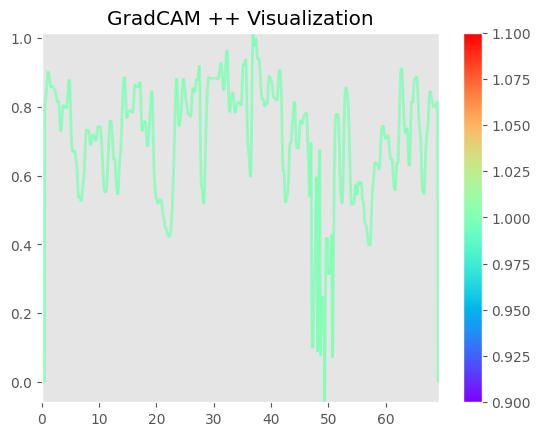

In [41]:
# First, second and third derivative of output gradient
y_c = tf.reshape(y_c, (-1, 1))  # Reshape y_c to have shape [1, 1] or [-1, 1] depending on your needs
first = tf.exp(y_c) * grads
second = tf.exp(y_c) * tf.pow(grads, 2)
third = tf.exp(y_c) * tf.pow(grads, 3)

# Compute salienty maps for the class_idx prediction
global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
alpha_num = second
alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1,1,first.shape[1]))
alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
alphas = alpha_num / alpha_denom
weights = tf.maximum(first, 0.0)
alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
alphas /= tf.reshape(alpha_normalization_constant, shape=(1,1,first.shape[1]))
alphas_thresholding = np.where(weights, alphas, 0.0)

alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0),axis=0)
alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                  tf.ones(alpha_normalization_constant.shape))

alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1,1,first.shape[1]))
deep_linearization_weights = tf.reduce_sum(tf.reshape((weights*alphas), shape=(-1,first.shape[1])), axis=0)
grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)

# Normalization
cam = np.maximum(grad_CAM_map, 0)
cam = cam / np.max(cam)

# Turn result into a heatmap
heatmap=[]
heatmap.append(cam.tolist())
big_heatmap = cv2.resize(np.array(heatmap), dsize=(data[0].shape[0], 500),interpolation=cv2.INTER_CUBIC)
x = np.linspace(0, 900, data[0].shape[0])
# plt.style.use("seaborn-whitegrid")
plt.style.use("ggplot")
# multicolored_lines(x,np.array([i[0] for i in data[0][:,2]]),big_heatmap[0],f"GradCAM ++ Visualization")
multicolored_lines(x[0:900],np.array([i[0] for i in reshaped_feature]),big_heatmap[0],f"GradCAM ++ Visualization")

In [ ]:
# print(predictions)
# print(predictions[0][:,0])
# predictions[0][class_idx.numpy(),0]
# class_idx.numpy()

# tf.argmax(predictions[0])
# predictions[0][tf.argmax(predictions[0])[1],1]
# class_idx = tf.argmax(predictions[0])
# y_c = predictions[0][class_idx.numpy()[0], 1]
# batch_grads = tape.gradient(y_c, conv_outs)
# batch_grads
# conv_outs.shape
# y_c
conv_outs.shape

In [ ]:
import tensorflow as tf

# Assuming conv_outs is a tensor of shape [11696, 2]
# conv_outs = tf.Variable(tf.ones((11696, 2)), trainable=True)

# Example list of scalar tensors
y_c_list = [tf.constant(1.0), tf.constant(0.9999776)]

# Convert the list of scalar tensors to a single tensor
y_c = tf.stack(y_c_list)

# Record operations for automatic differentiation
with tf.GradientTape() as tape:
    # Explicitly watch the tensor conv_outs
    tape.watch(conv_outs)
    
    # Define the loss as some operation involving conv_outs
    # For demonstration, we'll just sum conv_outs to create a scalar loss
    loss = tf.reduce_sum(conv_outs) + tf.reduce_sum(y_c)

# Calculate the gradient of the loss with respect to conv_outs
gradient = tape.gradient(loss, conv_outs)

if gradient is not None:
    print("Gradient shape:", gradient.shape)
    print("Gradient values:", gradient)
else:
    print("Gradient is None. Check if conv_outs is part of the watch list.")


In [ ]:
import tensorflow as tf

# Create a tensor with shape [11696, 2]
# conv_outs = tf.Variable(tf.random.normal((11696, 2)), trainable=True)

# Example list of scalar tensors
y_c_list = [tf.constant(0.859), tf.constant(0.59776)]

# Convert the list of scalar tensors to a single tensor
y_c = tf.stack(y_c_list)

# Record operations for automatic differentiation
with tf.GradientTape() as tape:
    tape.watch(conv_outs)
    # Define a more complex loss function
    predictions = conv_outs * 2.0  # For example purposes, let's assume this is the model's output
    loss = tf.reduce_mean((predictions - 1.0) ** 2) + tf.reduce_sum(y_c)  # Mean squared error + some constant term

# Calculate the gradient of the loss with respect to conv_outs
gradient = tape.gradient(loss, conv_outs)

if gradient is not None:
    print("Gradient shape:", gradient.shape)
    print("Gradient values:", gradient.numpy())
else:
    print("Gradient is None. Check if conv_outs is part of the watch list.")


In [26]:
random_tensor = tf.random.normal((11696, 1))
random_tensor.shape

TensorShape([11696, 1])

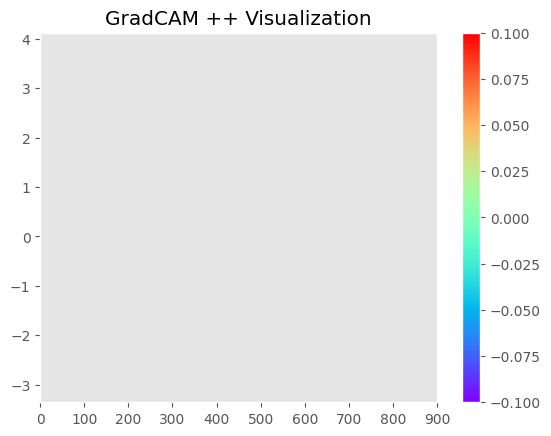

In [27]:
# First, second and third derivative of output gradient
y_c = tf.reshape(y_c, (-1, 1))  # Reshape y_c to have shape [1, 1] or [-1, 1] depending on your needs
first = tf.exp(y_c) * grads
second = tf.exp(y_c) * tf.pow(grads, 2)
third = tf.exp(y_c) * tf.pow(grads, 3)

# Compute salienty maps for the class_idx prediction
global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
alpha_num = second
alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1,1,first.shape[1]))
alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
alphas = alpha_num / alpha_denom
weights = tf.maximum(first, 0.0)
alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
alphas /= tf.reshape(alpha_normalization_constant, shape=(1,1,first.shape[1]))
alphas_thresholding = np.where(weights, alphas, 0.0)

alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0),axis=0)
alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                  tf.ones(alpha_normalization_constant.shape))

alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1,1,first.shape[1]))
deep_linearization_weights = tf.reduce_sum(tf.reshape((weights*alphas), shape=(-1,first.shape[1])), axis=0)
grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)

# Normalization
cam = np.maximum(grad_CAM_map, 0)
cam = cam / np.max(cam)

# Turn result into a heatmap
heatmap=[]
heatmap.append(cam.tolist())
big_heatmap = cv2.resize(np.array(heatmap), dsize=(data[0].shape[0], 500),interpolation=cv2.INTER_CUBIC)
x = np.linspace(0, 900, data[0].shape[0])
# plt.style.use("seaborn-whitegrid")
plt.style.use("ggplot")
# multicolored_lines(x,np.array([i[0] for i in data[0][:,2]]),big_heatmap[0],f"GradCAM ++ Visualization")
multicolored_lines(x,np.array([i[0] for i in random_tensor]),big_heatmap[0],f"GradCAM ++ Visualization")

In [33]:
# Choose the index of the sample you want to extract
sample_index = 0  # Change this to the desired sample index

# Extract one sample (shape: (900, 2))
sample = xav1[sample_index, :, :]

# Extract one feature from the sample (shape: (900,))
feature_index = 0  # Change this to 1 if you want the other feature
single_feature = sample[:, feature_index]

# Reshape the extracted feature to (900, 1, 1)
reshaped_feature = tf.reshape(single_feature, (900, 1))

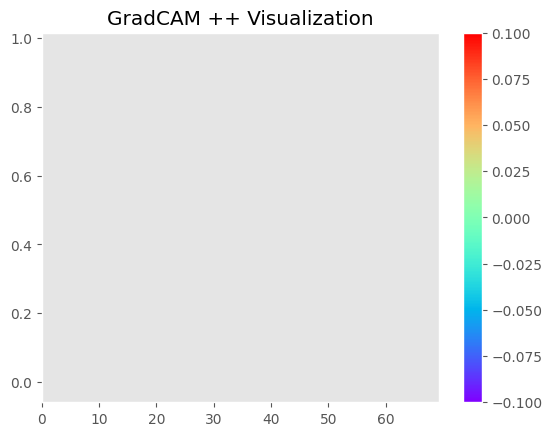

In [34]:
# First, second and third derivative of output gradient
y_c = tf.reshape(y_c, (-1, 1))  # Reshape y_c to have shape [1, 1] or [-1, 1] depending on your needs
first = tf.exp(y_c) * grads
second = tf.exp(y_c) * tf.pow(grads, 2)
third = tf.exp(y_c) * tf.pow(grads, 3)

# Compute salienty maps for the class_idx prediction
global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
alpha_num = second
alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1,1,first.shape[1]))
alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
alphas = alpha_num / alpha_denom
weights = tf.maximum(first, 0.0)
alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
alphas /= tf.reshape(alpha_normalization_constant, shape=(1,1,first.shape[1]))
alphas_thresholding = np.where(weights, alphas, 0.0)

alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0),axis=0)
alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                  tf.ones(alpha_normalization_constant.shape))

alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1,1,first.shape[1]))
deep_linearization_weights = tf.reduce_sum(tf.reshape((weights*alphas), shape=(-1,first.shape[1])), axis=0)
grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)

# Normalization
cam = np.maximum(grad_CAM_map, 0)
cam = cam / np.max(cam)

# Turn result into a heatmap
heatmap=[]
heatmap.append(cam.tolist())
big_heatmap = cv2.resize(np.array(heatmap), dsize=(data[0].shape[0], 500),interpolation=cv2.INTER_CUBIC)
x = np.linspace(0, 900, data[0].shape[0])
# plt.style.use("seaborn-whitegrid")
plt.style.use("ggplot")
# multicolored_lines(x,np.array([i[0] for i in data[0][:,2]]),big_heatmap[0],f"GradCAM ++ Visualization")
multicolored_lines(x[0:900],np.array([i[0] for i in reshaped_feature]),big_heatmap[0],f"GradCAM ++ Visualization")

In [435]:
# # [0, :, 1]
# data[0][0,:].shape
# sample.shape
# data[0].shape
# len(np.array([i[0] for i in data[0][:,0]]))
# data[0].shape
random_tensor.shape

TensorShape([11696, 1])

In [ ]:
from keras import backend as K
from keras.layers import Layer

is_keras_tensor = isinstance(conv_outs, Layer) or K.is_keras_tensor(conv_outs)
print("Is a Keras tensor?", is_keras_tensor)

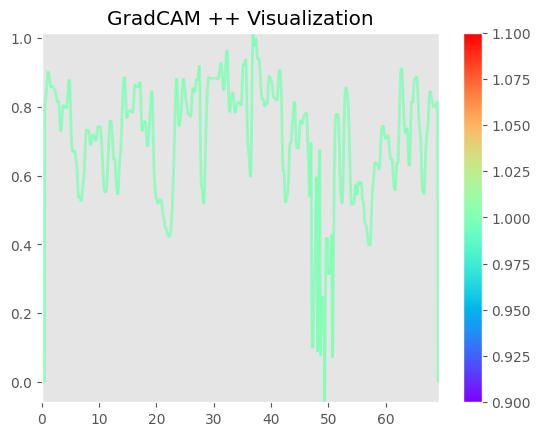

In [43]:
compute_cam_1d_output (model,[xav1, xav2, xav3],'Output_Layer',900)
# compute_cam_1d_output(model,np.squeeze(xav1[:1], axis=0),np.squeeze(xav2[:1], axis=0),np.squeeze(xav3[:1], axis=0),'Output_Layer',10)

In [28]:
import tensorflow as tf

# Assuming your tensor has the shape (11696, 900, 2)
tensor = tf.random.normal((11696, 900, 2))

# Choose the index of the sample you want to extract
sample_index = 0  # Change this to the desired sample index

# Extract one sample (shape: (900, 2))
sample = xav1[sample_index, :, :]

# Extract one feature from the sample (shape: (900,))
feature_index = 0  # Change this to 1 if you want the other feature
single_feature = sample[:, feature_index]

# Reshape the extracted feature to (900, 1, 1)
reshaped_feature = tf.reshape(single_feature, (900, 1))

# Print the shape to verify
print("Shape of the reshaped feature:", reshaped_feature.shape)
reshaped_feature
x

Shape of the reshaped feature: (900, 1)


array([0.00000000e+00, 7.69559641e-02, 1.53911928e-01, ...,
       8.99846088e+02, 8.99923044e+02, 9.00000000e+02])

In [32]:
data[0].shape

(11696, 900, 2)

# Modified

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def multicolored_lines(x, y, colors, title):
    """
    Plot multicolored lines.
    
    x: array-like, x-axis data
    y: array-like, y-axis data
    colors: array-like, color values for each point
    title: str, plot title
    """
    plt.figure()
    plt.scatter(x, y, c=colors, cmap='viridis')
    plt.colorbar(label='Color')
    plt.title(title)
    plt.show()

def compute_cam_1d_output(model, data1, data2, data3, layer_name, N):
    """
    Compute CAM 1D output.
    
    model: The Deep Learning model
    data1: Input data 1
    data2: Input data 2
    data3: Input data 3
    layer_name: The target layer for explanation
    N: Signal length in seconds
    """
    # Input layer, model output layer, and target layer
    grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.get_layer(layer_name).output, model.output])

    # Getting gradients of input layer, model output layer (predictions) and target layer
    with tf.GradientTape() as tape:
        inputs = [np.expand_dims(data1, axis=0), np.expand_dims(data2, axis=0), np.expand_dims(data3, axis=0)]
        conv_outs, predictions = grad_model(inputs)
        class_idx = tf.argmax(predictions[0])
        y_c = predictions[:, class_idx]

    batch_grads = tape.gradient(y_c, conv_outs)
    grads = batch_grads[0]

    # First, second, and third derivative of output gradient
    first = tf.exp(y_c) * grads
    second = tf.exp(y_c) * tf.pow(grads, 2)
    third = tf.exp(y_c) * tf.pow(grads, 3)

    # Compute saliency maps for the class_idx prediction
    print(conv_outs[0].shape)
    print(first.shape)

    # global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
    global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(1, -1)), axis=0)

    alpha_num = second
    # alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1, 1, first.shape[1]))
    alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1, 1, -1))
    
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
    alphas = alpha_num / alpha_denom
    weights = tf.maximum(first, 0.0)
    alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
    alphas /= tf.reshape(alpha_normalization_constant, shape=(1, 1, first.shape[1]))
    alphas_thresholding = np.where(weights, alphas, 0.0)

    alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0), axis=0)
    alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                      tf.ones(alpha_normalization_constant.shape))

    alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1, 1, first.shape[1]))
    deep_linearization_weights = tf.reduce_sum(tf.reshape((weights * alphas), shape=(-1, first.shape[1])), axis=0)
    grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)

    # Normalization
    cam = np.maximum(grad_CAM_map, 0)
    cam = cam / np.max(cam)

        # Turn result into a heatmap
    heatmap = []
    heatmap.append(cam.tolist())
    big_heatmap = cv2.resize(np.array(heatmap), dsize=(data1.shape[0], 500), interpolation=cv2.INTER_CUBIC)
    x = np.linspace(0, N, data1.shape[0])
    plt.style.use("seaborn-whitegrid")
    multicolored_lines(x, np.array([i[0] for i in data1]), big_heatmap[0], f"GradCAM ++ Visualization")



# Working but no graph, should see further

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def multicolored_lines(x, y, colors, title):
    """
    Plot multicolored lines.
    
    x: array-like, x-axis data
    y: array-like, y-axis data
    colors: array-like, color values for each point
    title: str, plot title
    """
    plt.figure()
    plt.scatter(x, y, c=colors, cmap='viridis')
    plt.colorbar(label='Color')
    plt.title(title)
    plt.show()

def compute_cam_1d_output(model, data1, data2, data3, layer_name, N):
    """
    Compute CAM 1D output.
    
    model: The Deep Learning model
    data1: Input data 1
    data2: Input data 2
    data3: Input data 3
    layer_name: The target layer for explanation
    N: Signal length in seconds
    """
    # Input layer, model output layer, and target layer
    grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.get_layer(layer_name).output, model.output])

    # Getting gradients of input layer, model output layer (predictions) and target layer
    with tf.GradientTape() as tape:
        inputs = [np.expand_dims(data1, axis=0), np.expand_dims(data2, axis=0), np.expand_dims(data3, axis=0)]
        conv_outs, predictions = grad_model(inputs)
        class_idx = tf.argmax(predictions[0])
        y_c = predictions[:, class_idx]

    batch_grads = tape.gradient(y_c, conv_outs)
    grads = batch_grads[0]

    # First, second, and third derivative of output gradient
    first = tf.exp(y_c) * grads
    second = tf.exp(y_c) * tf.pow(grads, 2)
    third = tf.exp(y_c) * tf.pow(grads, 3)

    # Compute saliency maps for the class_idx prediction
    global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(1, 2)), axis=0)
    alpha_num = second
    alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1, 1, tf.shape(first)[0]))
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
    alphas = alpha_num / alpha_denom
    weights = tf.maximum(first, 0.0)
    alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
    alphas /= tf.reshape(alpha_normalization_constant, shape=(1, 1, tf.shape(first)[0]))
    alphas_thresholding = np.where(weights, alphas, 0.0)

    alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0), axis=0)
    alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                      tf.ones(alpha_normalization_constant.shape))

    alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1, 1, tf.shape(first)[0]))
    deep_linearization_weights = tf.reduce_sum(tf.reshape((weights * alphas), shape=(-1, tf.shape(first)[0])), axis=0)
    grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)

    # Normalization
    cam = np.maximum(grad_CAM_map, 0)
    cam = cam / np.max(cam)

    # Turn result into a heatmap
    heatmap = []
    heatmap.append(cam.tolist())
    big_heatmap = cv2.resize(np.array(heatmap), dsize=(data1.shape[0], 500), interpolation=cv2.INTER_CUBIC)
    x = np.linspace(0, N, data1.shape[0])
    # plt.style.use("seaborn-whitegrid")
    plt.style.use('classic')

    multicolored_lines(x, np.array([i[0] for i in data1]), big_heatmap[0], f"GradCAM ++ Visualization")

# Example usage
# Assuming model is your TensorFlow model and data1, data2, data3 are your input data arrays
# compute_cam_1d_output(model, data1, data2, data3, 'target_layer_name', N=10)


In [ ]:
# compute_cam_1d_output(model,reshape_xav1_try[0:900],reshape_xav1_try[0:540],reshape_xav1_try[0:180],'Output_Layer',10)
compute_cam_1d_output(model,xav1_reshaped,xav2_reshaped,xav3_reshaped,'Output_Layer',10)

# New - Updated 22-05-2024 9:58 pm

In [ ]:
def multicolored_lines(x, y, colors, title):
    """
    Plot multicolored lines.
    
    x: array-like, x-axis data
    y: array-like, y-axis data
    colors: array-like, color values for each point
    title: str, plot title
    """
    plt.figure()
    plt.scatter(x, y, c=colors, cmap='viridis')
    plt.colorbar(label='Color')
    plt.title(title)
    plt.show()

def compute_cam_1d_output (model, data , layer_name , N):#Explainability
        """
        model: The Deep Learning model
        data : A input data. Data shape has to be (n,1,1)
        layer_name : The target layer for explanation
        N: signal length in seconds
        """
        # # input layer, model output layer and target layer
        # grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=[model.get_layer(layer_name).output, model.output])
        grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=model.output)

        # Getting gradients of input layer, model output layer (predictions) and target layer
        with tf.GradientTape() as tape:
            inputs = data #[np.expand_dims(data[0],axis=0),np.expand_dims(data[1],axis=0),np.expand_dims(data[2],axis=0)]
            conv_outs = grad_model(inputs)
            conv_outs, predictions = tf.split(conv_outs, num_or_size_splits=2, axis=1)
            class_idx = tf.argmax(predictions).numpy()[0]    #tf.argmax(predictions)
            y_c = predictions #[:, class_idx]

        print(y_c)
        print(conv_outs)
        batch_grads = tape.gradient(y_c, conv_outs)
        print(batch_grads)
        grads = batch_grads[0]

        # First, second and third derivative of output gradient
        y_c = tf.reshape(y_c, (-1, 1))  # Reshape y_c to have shape [1, 1] or [-1, 1] depending on your needs
        first = tf.exp(y_c) * grads
        second = tf.exp(y_c) * tf.pow(grads, 2)
        third = tf.exp(y_c) * tf.pow(grads, 3)

        # Compute salienty maps for the class_idx prediction
        global_sum = tf.reduce_sum(tf.reshape(conv_outs[0], shape=(-1, first.shape[1])), axis=0)
        alpha_num = second
        alpha_denom = second * 2.0 + third * tf.reshape(global_sum, shape=(1,1,first.shape[1]))
        alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones(shape=alpha_denom.shape))
        alphas = alpha_num / alpha_denom
        weights = tf.maximum(first, 0.0)
        alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas, axis=0), axis=0)
        alphas /= tf.reshape(alpha_normalization_constant, shape=(1,1,first.shape[1]))
        alphas_thresholding = np.where(weights, alphas, 0.0)

        alpha_normalization_constant = tf.reduce_sum(tf.reduce_sum(alphas_thresholding, axis=0),axis=0)
        alpha_normalization_constant_processed = tf.where(alpha_normalization_constant != 0.0, alpha_normalization_constant,
                                                          tf.ones(alpha_normalization_constant.shape))

        alphas /= tf.reshape(alpha_normalization_constant_processed, shape=(1,1,first.shape[1]))
        deep_linearization_weights = tf.reduce_sum(tf.reshape((weights*alphas), shape=(-1,first.shape[1])), axis=0)
        grad_CAM_map = tf.reduce_sum(deep_linearization_weights * conv_outs[0], axis=-1)

        # Normalization
        cam = np.maximum(grad_CAM_map, 0)
        cam = cam / np.max(cam)

        # Turn result into a heatmap
        heatmap=[]
        heatmap.append(cam.tolist())
        big_heatmap = cv2.resize(np.array(heatmap), dsize=(data.shape[0], 500),interpolation=cv2.INTER_CUBIC)
        x = np.linspace(0, N, data.shape[0])
        # plt.style.use("seaborn-whitegrid")
        plt.style.use("ggplot")
        multicolored_lines(x,np.array([i[0] for i in data]),big_heatmap[0],f"GradCAM ++ Visualization")

# Sample Run Code
compute_cam_1d_output(model,[xav1, xav2,xav3],'Output_Layer',10)

# Ignore the below

In [ ]:
# tf.argmax(predictions).numpy()[0]
conv_outs, predictions = grad_model(inputs)

In [ ]:
xav1[1:100].shape

In [ ]:
# grad_model = tf.keras.models.Model(inputs=model.inputs, outputs=model.output)
grad_model = tf.keras.models.Model(inputs=model.inputs, 
                                   outputs=[model.get_layer('Output_Layer').output, model.output])
data = [np.squeeze(xav1[:1], axis=0),np.squeeze(xav2[:1], axis=0),np.squeeze(xav3[:1], axis=0)]
# data = [temp_test1,temp_test2,temp_test3]
inputs = [np.expand_dims(data[0],axis=0),np.expand_dims(data[1],axis=0),np.expand_dims(data[2],axis=0)]

inputs = [xav1, xav2, xav3]
# conv_outs, predictions  = grad_model(model.inputs)
conv_outs, predictions = grad_model(inputs)#= tf.split(out_temp, num_or_size_splits=2, axis=1)
print(conv_outs)
print(predictions)

# try
conv_outs, predictions = tf.split(conv_outs, num_or_size_splits=2, axis=1)
print(conv_outs)
print(predictions)


In [ ]:
# tf.argmax(predictions).numpy()[0]
# predictions[8848,:]
# y_c = predictions #[:, class_idx]
# y_c
batch_grads = tape.gradient(y_c, conv_outs)
        # grads = batch_grads[0]

In [ ]:
print(xav1.shape)
print(xav2.shape)
print(xav3.shape)
print(np.squeeze(xav1[:1], axis=0).shape)
print(np.expand_dims(data[0],axis=0).shape)
print(xav1[1].shape)

In [ ]:
print(predictions)
xavx,xavy =tf.split(out_temp, num_or_size_splits=2, axis=1)
print(xavx)
print(xavy)

In [ ]:
# model.inputs[2].shape
# xav1.shape
# print(model.get_layer('Output_Layer').output)
# print(model.output)
# compute_cam_1d_output (model,[xav1, xav2, xav3],'Output_Layer',10)

compute_cam_1d_output(model,[xav1, xav2,xav3],'Output_Layer',10)

# 26-05-2024

In [ ]:
model.inputs